##### Logistic regression for binary classification on fruits dataset using height, width features (positive class: apple, negative class: others)

In [3]:
from sklearn.linear_model import LogisticRegression
from adspy_shared_utilities import(plot_class_regions_for_classifier_subplot)
import matplotlib.pyplot as plt

A fruit with height 6 and width 8 is predicted to be: an apple
A fruit with height 10 and width 7 is predicted to be: not an apple
Accuracy of Logistic regression classifier on training set: 0.80
Accuracy of Logistic regression classifier on test set: 0.73


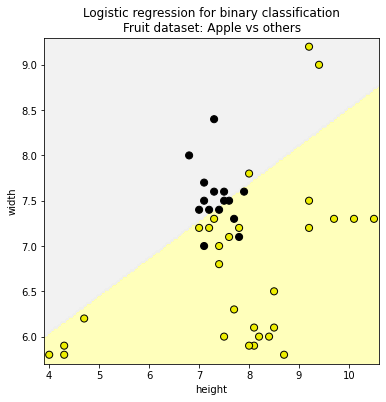

In [40]:
#subplot = Add an Axes to the current figure or retrieve an existing Axes.
#Create a figure and a set of subplots.
import pandas as pd
from sklearn.model_selection import train_test_split

fig, subaxes = plt.subplots(nrows=1, ncols =1,  figsize=(6,6))

fruits = pd.read_table('assets/fruit_data_with_colors.txt')

feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
y_fruits = fruits['fruit_label']
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']
X_fruits_2d
y_fruits_apple = y_fruits_2d==1 # make the classification into a binary problem: apple vs everything else 


X_train, X_test, y_train, y_test = (
train_test_split(X_fruits_2d.values,
                y_fruits_apple,
                random_state = 0))
clf = LogisticRegression(C=100).fit(X_train,y_train)


plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None,
                                         None, 'Logistic regression \
for binary classification\nFruit dataset: Apple vs others',
                                         subaxes)

h=6
w=8
prediction = int(clf.predict([[h,w]]))

print('A fruit with height {} and width {} is predicted to be: {}'
     .format(h,w, ['not an apple', 'an apple'][prediction]))

h = 10
w = 7
print('A fruit with height {} and width {} is predicted to be: {}'
     .format(h,w, ['not an apple', 'an apple'][int(clf.predict([[h,w]])[0])]))
subaxes.set_xlabel('height')
subaxes.set_ylabel('width')

print('Accuracy of Logistic regression classifier on training set: {:.2f}'
      .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
      .format(clf.score(X_test, y_test)))


#### Logistic Regression regularization: C parameter

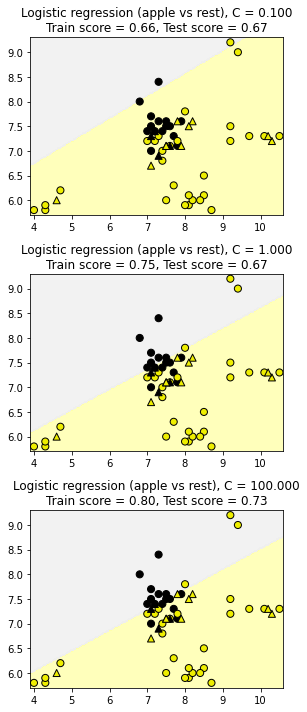

In [46]:
X_train, X_test, y_train, y_test = (
train_test_split(X_fruits_2d.values,
                y_fruits_apple.values,
                random_state=0))

fig, subaxes = plt.subplots(3, 1, figsize=(4, 10))

for this_C, subplot in zip([0.1, 1, 100], subaxes):
    clf = LogisticRegression(C=this_C).fit(X_train, y_train)
    title ='Logistic regression (apple vs rest), C = {:.3f}'.format(this_C)
    
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train, X_test, y_test,title, subplot)
                                          #   X_test, y_test, title,
                                             
plt.tight_layout()